B.1. Write Python code to implement a regression model for weather forecasting.
Compare simple regression, Ridge regression, and Lasso regression.

Simple linear regration consists of main 3 functions: 
1. main regration function for prediction
    $
    y = mx + b
    $

2. Error Function 
$E = \frac{1}{m}\sum_{i=0}^{n}{(yi - (mx + b))^2}$

our main goal is to find $\textbf{m}$ and $\textbf{b}$ where the $\textbf{E}$ is minimum

so for the minimum of $\textbf{E}$ 

1. $\frac{\delta{E}}{\delta{m}} = -\frac{1}{n}\sum_{i=0}^{n}{x(yi - (mx + b))}$

2. $\frac{\delta{E}}{\delta{b}} = -\frac{2}{n}\sum_{i=0}^{n}{(yi - {mx + b})}$

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
weather_data = pd.read_csv('/home/rito/ju_class/weather.csv')
weather_df = pd.DataFrame(weather_data)
print(weather_df)

     MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine WindGustDir  \
0        8.0     24.3       0.0          3.4       6.3          NW   
1       14.0     26.9       3.6          4.4       9.7         ENE   
2       13.7     23.4       3.6          5.8       3.3          NW   
3       13.3     15.5      39.8          7.2       9.1          NW   
4        7.6     16.1       2.8          5.6      10.6         SSE   
..       ...      ...       ...          ...       ...         ...   
361      9.0     30.7       0.0          7.6      12.1         NNW   
362      7.1     28.4       0.0         11.6      12.7           N   
363     12.5     19.9       0.0          8.4       5.3         ESE   
364     12.5     26.9       0.0          5.0       7.1          NW   
365     12.3     30.2       0.0          6.0      12.6          NW   

     WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  ...  Humidity3pm  \
0             30.0         SW         NW           6.0  ...           29   
1      

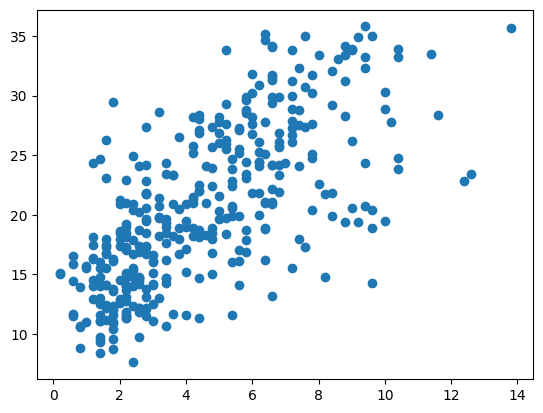

In [11]:
plt.scatter(weather_df.Evaporation,weather_df.MaxTemp)
plt.show()

In [12]:
#error function
def errror_func(m,b,x,y):
    total_error = 0
    for i in range(len(x)):
        total_error += (y - (m*x + b))**2
    total_error / float(len(x))
    return total_error

In [27]:
def gradient_decent(m_now, b_now, x, y, L):
    m_grad = 0
    b_grad = 0

    n = len(x)

    for i in range(n):
        m_grad += -(2/n)*(y[i] - (m_now*x[i] + b_now)) * x[i]
        b_grad += -(2/n)*(y[i] - (m_now*x[i] + b_now))

    m_l = m_now - L * m_grad
    b_l = b_now - L * b_grad
    
    return (m_l,b_l)

Epoches: 0
Epoches: 50
Epoches: 100
Epoches: 150
Epoches: 200
Epoches: 250
Epoches: 300
Epoches: 350
Epoches: 400
Epoches: 450
Epoches: 500
Epoches: 550
Epoches: 600
Epoches: 650
Epoches: 700
Epoches: 750
Epoches: 800
Epoches: 850
Epoches: 900
Epoches: 950
3.624316514375365 1.2097101773028


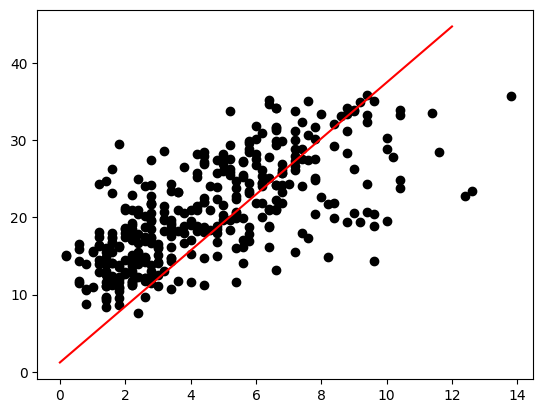

In [33]:
m = 0 
b = 0
L = 0.0001
epochs = 1000

for i in range(epochs):
    if i % 50 == 0:
        print(f"Epoches: {i}")
    m, b  = gradient_decent(m,b,weather_df.Evaporation,weather_df.MaxTemp,L)

print(m,b)

plt.scatter(weather_df.Evaporation,weather_df.MaxTemp, color="black")
plt.plot(list(range(int(min(weather_df.Evaporation)),int(max(weather_df.Evaporation)))),[m*x + b for x in range(int(min(weather_df.Evaporation)),int(max(weather_df.Evaporation)))], color = "red")
plt.show()